<a href="https://colab.research.google.com/github/DevikaRelangi-glitch/Worlflow1/blob/main/Tesco_Grocery_set_Analysis_using_SPARK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Import all the neccessary libraries**

In [ ]:
# Import neccessary libraries
from pyspark.sql import SparkSession
from pyspark.sql.functions import when, lit, col, mean, stddev, median
from pyspark.sql.types import StructType, StructField, StringType, DoubleType, IntegerType
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy import stats

**Creating a session for spark**

In [ ]:
# Initialize a Spark session
spark = SparkSession.builder.appName("TescoGroceryAnalysis").getOrCreate()

**Reading files from directory:**

Loop through for loop to read all the files from the Tesco Grocery data set. After reading the files from directory. Extract month name from filename and insert a new column to store the month name. Also to create a new column to store the season of that particular month. An if statement is written to handle the seasons.

In [ ]:
# Read the Tesco grocery dataset from CSV files in the specified directory
data_directory = "/content/drive/MyDrive/Tesco Grocery Data set/"
df_list = []  # Create a list to store dataframes

for filename in os.listdir(data_directory):
    if filename.endswith(".csv"):

        filename_path = os.path.join(data_directory, filename)
        month_name = filename.split("_")[0].lower()  # Extract month name

        df_temp = spark.read.csv(filename_path, header=True, inferSchema=True)
        df_temp = df_temp.withColumn("month", lit(month_name))  # Assign the month

        df_list.append(df_temp)  # Add the temp df to the list

# Combine all dataframes into a single dataframe
df = df_list[0]  # Initialize with the first dataframe
for df_temp in df_list[1:]:
    df = df.unionAll(df_temp)  # Use unionAll to combine dataframes

# Add season column
df = df.withColumn("season", when(df["month"].isin(["may", "jun", "jul", "aug", "sep"]), lit("summer")).otherwise(lit("winter")))

# Select specific columns and remove duplicates
df = df.select("area_id", "energy_density", "fibre", "sugar", "month", "season").distinct()
df.show()

+---------+-------------------+------------------+------------------+-----+------+
|  area_id|     energy_density|             fibre|             sugar|month|season|
+---------+-------------------+------------------+------------------+-----+------+
|E01000277| 0.4287984397954673|1.7533310976973024|  9.18331991951706|  feb|winter|
|E01000523| 0.4392211367544112|1.5678545963839865| 9.289882862235963|  feb|winter|
|E01000588| 0.3862185167001125| 1.735486322188454| 9.600258358662566|  feb|winter|
|E01000797| 0.6392144900367221|1.5436156351791546|12.096123778501587|  feb|winter|
|E01001145| 0.5281915738975815|1.5727887323943746|11.638619718309805|  feb|winter|
|E01002481| 0.4658718776448326|1.5534281716418057|  10.6349634861409|  feb|winter|
|E01002548| 0.6546936431398263|1.5266393442622939|11.297267759562844|  feb|winter|
|E01003194| 0.4354227223146763|1.5413615560640626|10.597463529748321|  feb|winter|
|E01003282|0.43049735523377897|1.6611999094407923| 8.894707946570074|  feb|winter|
|E01

**Data Transformation:**

As part of data transformation, create a new column called 'sugar_to_fibre' to store the ratio of sugar to fibre across each column.


In [ ]:
from pyspark.sql.functions import round ,to_number
# Calculate sugar_to_fibre_ratio
df = df.withColumn("sugar_to_fibre_ratio", round(col("sugar") / col("fibre"),2))


**Statistical Overview:**

To understand the descriptive statics of the numerical data with help of describe(). This helps in finding out the count, mean, standard deviation, smallest value, 25%, 50%, 75% and the largest value of the dataframe.

In [ ]:
df.describe().show()

+-------+---------+-------------------+-------------------+------------------+-----+------+--------------------+
|summary|  area_id|     energy_density|              fibre|             sugar|month|season|sugar_to_fibre_ratio|
+-------+---------+-------------------+-------------------+------------------+-----+------+--------------------+
|  count|    51295|              51295|              51295|             51295|51295| 51295|               51295|
|   mean|     NULL| 0.4842041954673979| 1.6207280401234672|10.161997306325446| NULL|  NULL|  6.3119027195633475|
| stddev|     NULL|0.08473314524656266|0.14196728187321753|1.3899174385710251| NULL|  NULL|  1.0618853226888236|
|    min|E01000001|0.17055924193672914| 0.5003894080996883|   5.5263467632413|  apr|summer|                0.64|
|    max|E01033746|  4.464638221869963| 13.109171701561012|45.078777589136465|  sep|winter|               45.51|
+-------+---------+-------------------+-------------------+------------------+-----+------+-----

**Overview:**

Overview of the final filtered data required for actual data analysis.

In [ ]:
df.show()

+---------+-------------------+------------------+------------------+-----+------+--------------------+
|  area_id|     energy_density|             fibre|             sugar|month|season|sugar_to_fibre_ratio|
+---------+-------------------+------------------+------------------+-----+------+--------------------+
|E01000277| 0.4287984397954673|1.7533310976973024|  9.18331991951706|  feb|winter|                5.24|
|E01000523| 0.4392211367544112|1.5678545963839865| 9.289882862235963|  feb|winter|                5.93|
|E01000588| 0.3862185167001125| 1.735486322188454| 9.600258358662566|  feb|winter|                5.53|
|E01000797| 0.6392144900367221|1.5436156351791546|12.096123778501587|  feb|winter|                7.84|
|E01001145| 0.5281915738975815|1.5727887323943746|11.638619718309805|  feb|winter|                 7.4|
|E01002481| 0.4658718776448326|1.5534281716418057|  10.6349634861409|  feb|winter|                6.85|
|E01002548| 0.6546936431398263|1.5266393442622939|11.29726775956

Conerting spark to pandas for visualization using pandas.

In [ ]:
df_P=df.toPandas()

**Count of months**

To plot count of months with respect to season

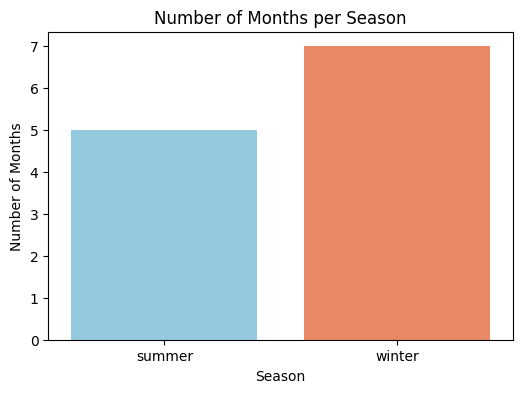

In [ ]:
# Group data by season and count unique months
month_counts = df_P.groupby('season')['month'].nunique().reset_index()

# Create the bar plot
plt.figure(figsize=(6, 4))
sns.barplot(x='season', y='month', data=month_counts, palette=['skyblue', 'coral'], hue = 'season')
plt.title('Number of Months per Season')
plt.xlabel('Season')
plt.ylabel('Number of Months')
plt.savefig('MONTHS.png')
plt.show()

**Visualise the energy density of food purchases across LSOAs in winter (October-April) and in summer (May-September).**

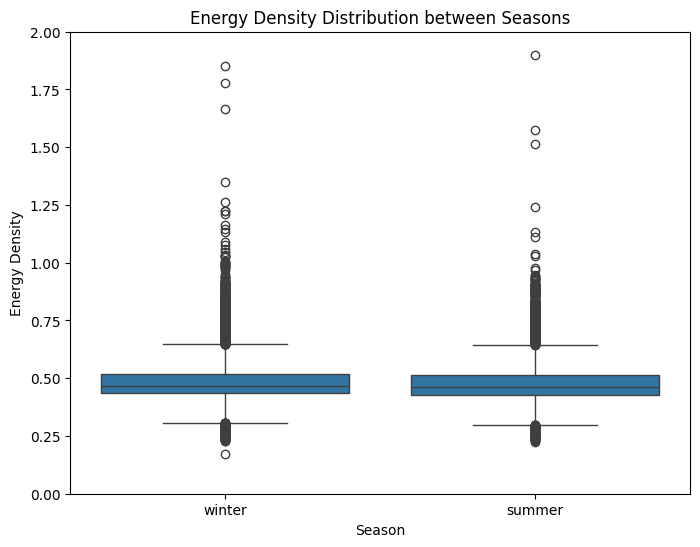

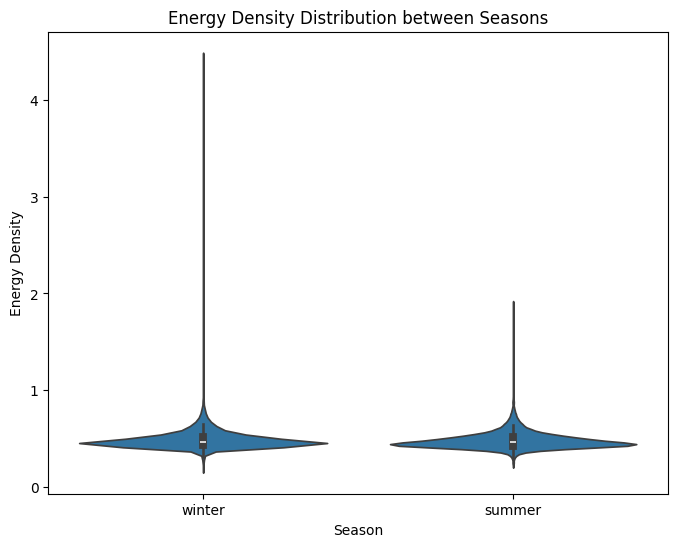

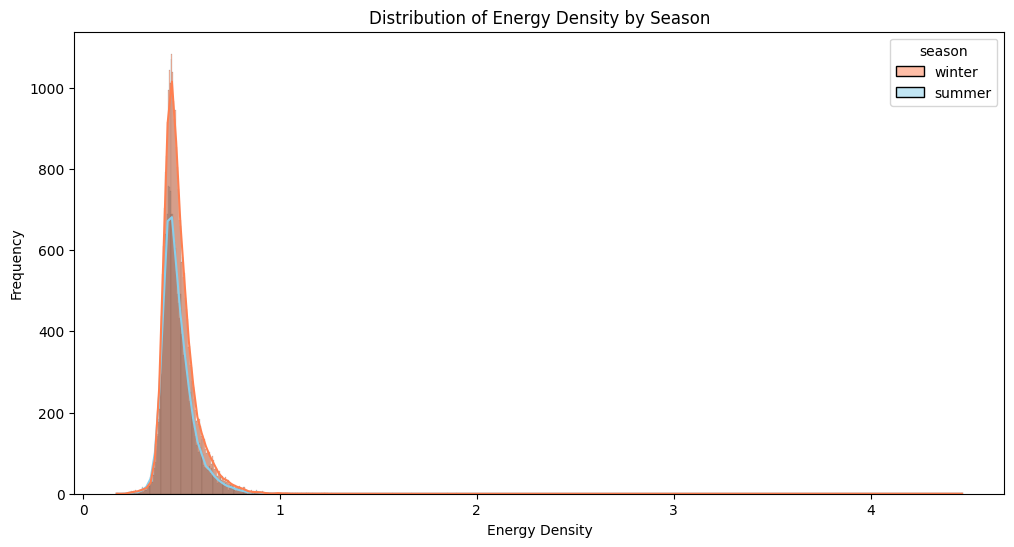

In [ ]:
# Create a boxplot to visualize energy density distribution between seasons
plt.figure(figsize=(8, 6))  # Adjust figure size
sns.boxplot(x='season', y='energy_density', data=df_P)
plt.title('Energy Density Distribution between Seasons')
plt.xlabel('Season')
plt.ylabel('Energy Density')
plt.ylim(0, 2)
plt.savefig('ED_BOX.png')
plt.show()

# create a violin plot for a more detailed view
plt.figure(figsize=(8, 6))  # Adjust figure size
sns.violinplot(x='season', y='energy_density', data=df_P)
plt.title('Energy Density Distribution between Seasons')
plt.xlabel('Season')
plt.ylabel('Energy Density')
plt.show()

# Create a histplot for a more detailed view
plt.figure(figsize=(12, 6))  # Adjust figure size
sns.histplot(data=df_P, x='energy_density', hue='season', kde = True,
             palette={'winter': 'coral', 'summer': 'skyblue'})
plt.title('Distribution of Energy Density by Season')
plt.xlabel('Energy Density')
plt.ylabel('Frequency')
plt.show()

**Aggregations**

Calculate the total sum of energy density and sugar to fibre ratios with respect to each season.

        energy_density  sugar_to_fibre_ratio
season                                      
summer    10202.838466             130687.53
winter    14634.415740             193081.52


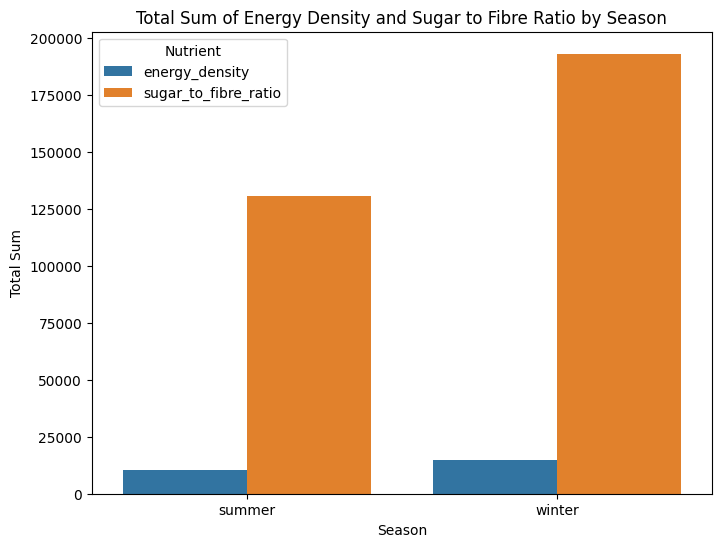

In [ ]:
# Group data by season and calculate the sum of energy density and sugar_to_fibre_ratio
season_sums = df_P.groupby('season')[['energy_density', 'sugar_to_fibre_ratio']].sum()

# Display the results
print(season_sums)

# Reshape the DataFrame into a long format suitable for seaborn
season_sums_melted = pd.melt(season_sums.reset_index(), id_vars=['season'],
                             value_vars=['energy_density', 'sugar_to_fibre_ratio'],
                             var_name='Nutrient', value_name='Total Sum')

# Create a bar plot using seaborn
plt.figure(figsize=(8, 6))
sns.barplot(x='season', y='Total Sum', hue='Nutrient', data=season_sums_melted)
plt.title('Total Sum of Energy Density and Sugar to Fibre Ratio by Season')
plt.xlabel('Season')
plt.ylabel('Total Sum')
plt.savefig('SUM.png')
plt.show()



**a.	Is there a difference between energy density according to season?**

**b.	What about the ratio of sugar to fibre?**

To answer part of the question difference is calculated from the overall sums of nutrients with respect seasons.

               Nutrient    Difference
0        Energy Density   4431.577274
1  Sugar to Fibre Ratio  62393.990000


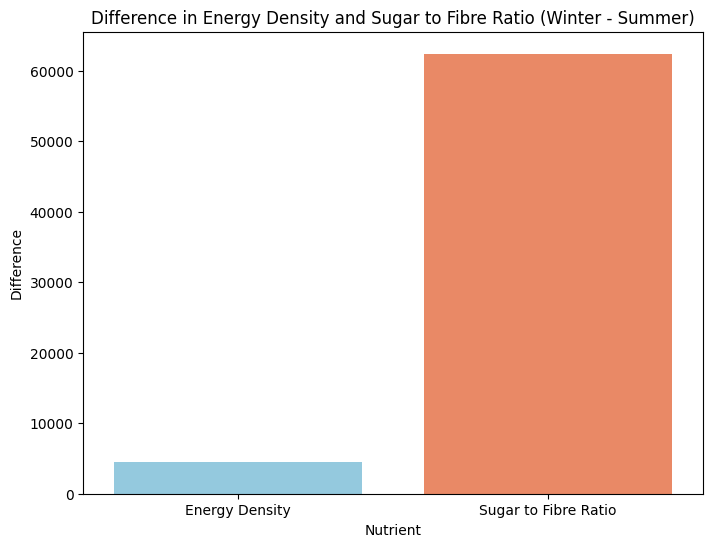

In [ ]:
# Calculate the difference directly
diff_energy_density = season_sums.loc['winter', 'energy_density'] - \
                      season_sums.loc['summer', 'energy_density']

diff_sugar_to_fibre = season_sums.loc['winter', 'sugar_to_fibre_ratio'] - \
                      season_sums.loc['summer', 'sugar_to_fibre_ratio']

# Create a DataFrame for plotting
diff_data = {'Nutrient': ['Energy Density', 'Sugar to Fibre Ratio'],
             'Difference': [diff_energy_density, diff_sugar_to_fibre]}
diff_df = pd.DataFrame(diff_data)

print(diff_df)

# Create the bar plot with custom colors
plt.figure(figsize=(8, 6))
sns.barplot(x='Nutrient', y='Difference', data=diff_df, hue = 'Nutrient',
            palette=['skyblue', 'coral'])  # Specify colors for each bar
plt.title('Difference in Energy Density and Sugar to Fibre Ratio (Winter - Summer)')
plt.xlabel('Nutrient')
plt.ylabel('Difference')
plt.savefig('DIFF.png')
plt.show()

**Statistical visiualization of energy density and sugar to fibre ratio together:**

Statistical visualization to represent the visualization between 'energy_density' and 'sugar_to_fibre' ratio.

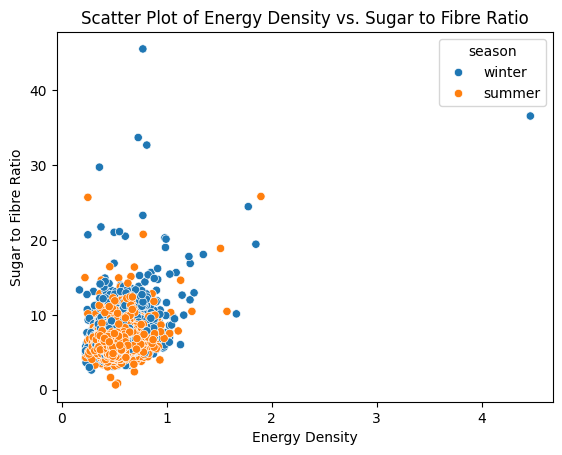

In [ ]:
# Create a scatter plot using Seaborn
sns.scatterplot(x='energy_density', y='sugar_to_fibre_ratio', hue='season', data=df_P)
# Set title and labels for better readability
plt.title('Scatter Plot of Energy Density vs. Sugar to Fibre Ratio')
plt.xlabel('Energy Density')
plt.ylabel('Sugar to Fibre Ratio')
plt.savefig('SCATTER.png')
plt.show()



Means of energy densities and sugar to fibre ratio with respect to season

In [ ]:
# Calculate means by season
means_by_season = df_P.groupby('season')[['energy_density', 'sugar_to_fibre_ratio']].mean()

# Display the results
print(means_by_season)

        energy_density  sugar_to_fibre_ratio
season                                      
summer        0.480201              6.150870
winter        0.487035              6.425769


**Visualise the sugar to fibre ratio of food purchases across LSOAs in winter (October-April) and in summer (May-September).**

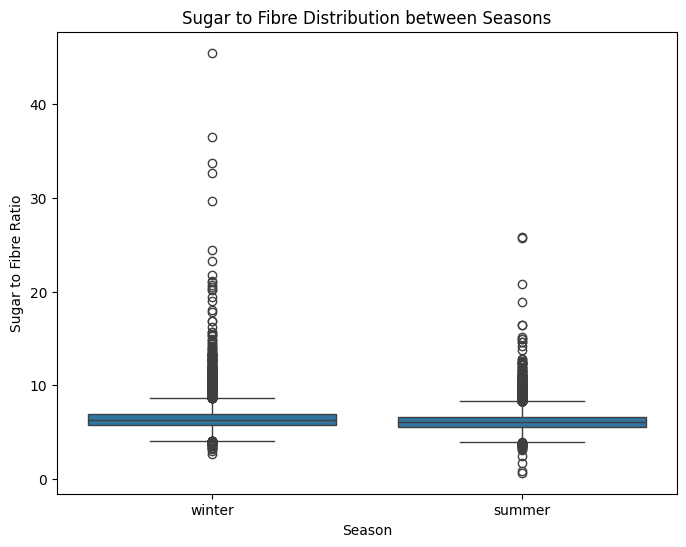

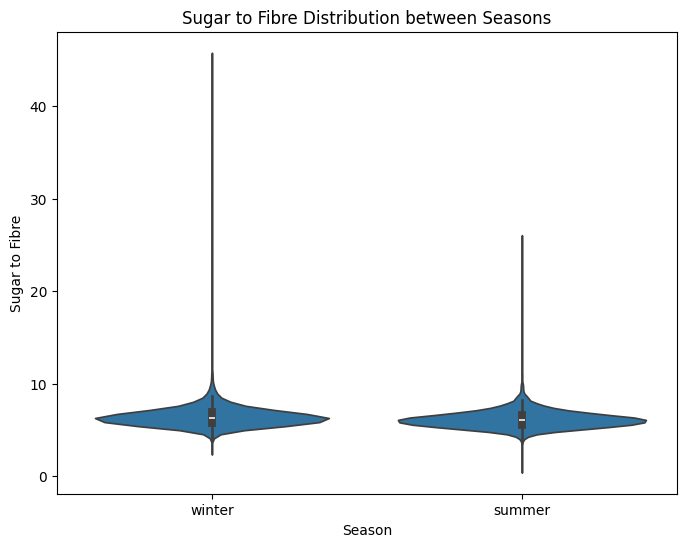

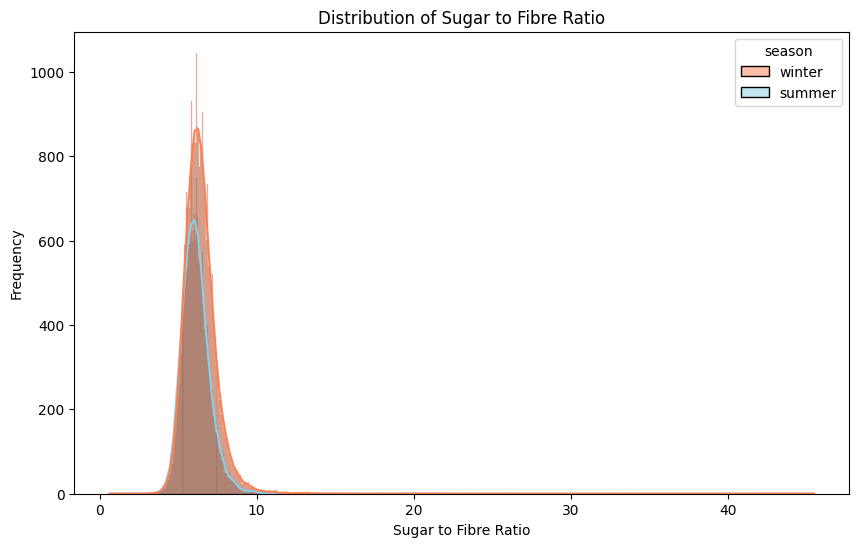

In [ ]:
# Create a boxplot to visualize energy density distribution between seasons
plt.figure(figsize=(8, 6))
sns.boxplot(x='season', y='sugar_to_fibre_ratio', data=df_P)
plt.title('Sugar to Fibre Distribution between Seasons')
plt.xlabel('Season')
plt.ylabel('Sugar to Fibre Ratio')
plt.savefig('SF_BOX.png')
plt.show()

# Alternatively, you can create a violin plot for a more detailed view
plt.figure(figsize=(8, 6))
sns.violinplot(x='season', y='sugar_to_fibre_ratio', data=df_P)
plt.title('Sugar to Fibre Distribution between Seasons')
plt.xlabel('Season')
plt.ylabel('Sugar to Fibre')
plt.savefig('SF_VP.png')
plt.show()

# Create the histogram using seaborn's histplot
plt.figure(figsize=(10, 6))
sns.histplot(data=df_P, x='sugar_to_fibre_ratio', hue='season',kde=True,
             palette={'winter': 'coral', 'summer': 'skyblue'})
plt.title('Distribution of Sugar to Fibre Ratio')
plt.xlabel('Sugar to Fibre Ratio')
plt.ylabel('Frequency')
plt.savefig('SF_HP.png')
plt.show()

**Statistical test:**

A statistical test called two smaple test is performed to find there is a significant difference in the energy density and sugar to fibre ratio of the food sold during winter and summer.

where t_statistic_energy respresents the difference of means scaled by variability.

In [ ]:
# T-test for Energy Density between Seasons
summer_energy_density = df.filter(df["season"] == "summer").select("energy_density").rdd.flatMap(lambda x: x).collect()
winter_energy_density = df.filter(df["season"] == "winter").select("energy_density").rdd.flatMap(lambda x: x).collect()
t_statistic, p_value = stats.ttest_ind(summer_energy_density, winter_energy_density)
print("T-statistic for Energy Density:", t_statistic)
print("P-value for Energy Density:", p_value)

# T-test for Sugar to Fibre ratio between Seasons
summer_sugar_to_fibre = df.filter(df["season"] == "summer").select("sugar_to_fibre_ratio").rdd.flatMap(lambda x: x).collect()
winter_sugar_to_fibre = df.filter(df["season"] == "winter").select("sugar_to_fibre_ratio").rdd.flatMap(lambda x: x).collect()
t_statistic, p_value = stats.ttest_ind(summer_sugar_to_fibre, winter_sugar_to_fibre)
print("T-statistic for Energy Density:", t_statistic)
print("P-value for Energy Density:", p_value)

T-statistic for Energy Density: -9.003902546641493
P-value for Energy Density: 2.2509355117383973e-19
T-statistic for Energy Density: -29.11867690925414
P-value for Energy Density: 6.721475012190753e-185


In [ ]:
# Stop the Spark session
spark.stop()